<a href="https://colab.research.google.com/github/CodeHunterOfficial/ArabovMKDeep/blob/main/DL-2026/Lecture_3/Lecture_3_Convolutional_Neural_Networks_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Часть I. Свёрточные нейронные сети: математические основы, прямой проход и обратное распространение

### 1. Введение в свёрточные нейронные сети

Свёрточные нейронные сети (Convolutional Neural Networks, CNN) представляют собой специализированный класс нейронных сетей, предназначенный прежде всего для обработки данных, имеющих сеточную структуру: изображений, временных рядов, аудиоспектрограмм, объёмных данных. В отличие от полносвязных многослойных перцептронов (MLP), в которых каждый нейрон соединён со всеми нейронами предыдущего слоя, CNN используют **локальные связи** и **разделяемые веса**, что резко сокращает число параметров и позволяет эффективно извлекать пространственные или временные признаки.

Основные идеи CNN:
- **Локальное восприятие**: каждый нейрон свёрточного слоя соединён только с небольшой областью входного объёма (рецептивным полем).
- **Разделяемые веса**: один и тот же фильтр (ядро свёртки) применяется ко всем пространственным позициям, обеспечивая инвариантность к сдвигу.
- **Иерархия признаков**: более глубокие слои комбинируют низкоуровневые признаки (рёбра, текстуры) в высокоуровневые (части объектов, объекты).
- **Пулинг**: уменьшение пространственного разрешения для достижения инвариантности к небольшим смещениям и сокращения вычислений.

В первой части мы подробно рассмотрим математические основы CNN: операцию свёртки, прямой проход через свёрточные, пулинговые и полносвязные слои, а также алгоритм обратного распространения ошибки для этих слоёв. Для простоты будем рассматривать двумерные свёртки на изображениях, хотя идеи легко обобщаются на другие размерности.

### 2. Операция свёртки

#### 2.1. Определение двумерной корреляции (свёртки в контексте глубокого обучения)

Пусть дано двумерное изображение (карта признаков) $\mathbf X$ размера $H \times W$ и фильтр (ядро) $\mathbf K$ размера $k_h \times k_w$. Корреляция $\mathbf X$ с фильтром $\mathbf K$ (без padding и stride) даёт выходную карту $\mathbf Y$ размера $(H - k_h + 1) \times (W - k_w + 1)$, элементы которой вычисляются как

$$
Y_{i,j} = \sum_{p=0}^{k_h-1} \sum_{q=0}^{k_w-1} X_{i+p, j+q} K_{p,q} + b,
$$

где $b$ — смещение (bias). В машинном обучении эту операцию часто называют свёрткой, хотя математически строгая свёртка предполагает отражение ядра. Мы будем следовать общепринятой в глубоком обучении терминологии, где ядро не переворачивается.

В более общем виде с учётом **padding** $P$ и **stride** $S$ размер выхода определяется как

$$
H_{\text{out}} = \left\lfloor \frac{H + 2P - k_h}{S} \right\rfloor + 1, \qquad
W_{\text{out}} = \left\lfloor \frac{W + 2P - k_w}{S} \right\rfloor + 1.
$$

Padding добавляет нули по краям входа, чтобы контролировать размер выхода. Stride задаёт шаг смещения фильтра.

#### 2.2. Многоканальные входы и множественные фильтры

В общем случае вход свёрточного слоя — это тензор $\mathbf X$ размера $C_{\text{in}} \times H \times W$, где $C_{\text{in}}$ — число каналов (например, 3 для RGB-изображения). Слой имеет $C_{\text{out}}$ фильтров, каждый размера $C_{\text{in}} \times k_h \times k_w$. Для каждого выходного канала $c$ вычисляется свёртка по всем входным каналам:

$$
\mathbf Z_{c,:,:} = \sum_{d=1}^{C_{\text{in}}} \mathbf X_{d,:,:} * \mathbf K_{c,d,:,:} + b_c,
$$

где $*$ обозначает двумерную корреляцию, $b_c$ — смещение для канала $c$. Результат $\mathbf Z$ имеет размер $C_{\text{out}} \times H_{\text{out}} \times W_{\text{out}}$. Количество параметров слоя равно $C_{\text{out}} \cdot (C_{\text{in}} \cdot k_h \cdot k_w + 1)$.

#### 2.3. Представление свёртки через im2col

Свёрточный слой можно представить как полносвязный с разреженной матрицей весов. Для этого используется метод im2col: из входного тензора формируется матрица $\mathbf X_{\text{col}}$ размера $(C_{\text{in}} \cdot k_h \cdot k_w) \times (H_{\text{out}} \cdot W_{\text{out}})$, в которой каждый столбец соответствует одному положению фильтра и содержит все пиксели рецептивного поля в виде вектора. Веса фильтров также разворачиваются в матрицу $\mathbf W$ размера $C_{\text{out}} \times (C_{\text{in}} \cdot k_h \cdot k_w)$. Тогда свёртка записывается как матричное умножение:

$$
\mathbf Z = \mathbf W \mathbf X_{\text{col}} + \mathbf b,
$$

где $\mathbf b$ — вектор смещений размера $C_{\text{out}}$. Это представление удобно для реализации на GPU и для вывода градиентов, хотя и требует дополнительной памяти.

### 3. Прямой проход через слои CNN

Типичная CNN состоит из последовательности свёрточных слоёв, перемежаемых слоями активации и пулинга, после которых идут один или несколько полносвязных слоёв для классификации или регрессии.

#### 3.1. Свёрточный слой и функция активации

Как описано выше, свёрточный слой применяет фильтры к входному тензору, получая линейные активации $\mathbf Z$. Затем поэлементно применяется нелинейная функция активации (обычно ReLU):

$$
\mathbf A = \sigma(\mathbf Z),
$$

где $\sigma$ — функция активации (например, ReLU). Если используется Batch Normalization, то она обычно вставляется до активации.

#### 3.2. Слой пулинга

Пулинг уменьшает пространственное разрешение карт признаков. Наиболее распространены **max pooling** и **average pooling**.

Пусть на входе карта размера $H \times W$, а окно пулинга $p \times p$ и stride $s$. Выход имеет размер $\lfloor (H-p)/s \rfloor + 1 \times \lfloor (W-p)/s \rfloor + 1$. Для max pooling:

$$
Y_{i,j} = \max_{u=0}^{p-1} \max_{v=0}^{p-1} X_{i s + u, j s + v}.
$$

Для average pooling:

$$
Y_{i,j} = \frac{1}{p^2} \sum_{u=0}^{p-1} \sum_{v=0}^{p-1} X_{i s + u, j s + v}.
$$

Пулинг обычно применяется независимо к каждому каналу, не изменяя число каналов.

#### 3.3. Полносвязный слой

После нескольких свёрточных и пулинговых слоёв выходной тензор вытягивается в вектор (flatten) и подаётся на один или несколько полносвязных слоёв, как в MLP. Для задачи классификации на $C$ классов последний полносвязный слой имеет $C$ нейронов с softmax активацией.

### 4. Обратное распространение ошибки в CNN

Обучение CNN также основано на градиентном спуске, а градиенты вычисляются алгоритмом обратного распространения. Необходимо уметь вычислять градиенты функции потерь $L$ по параметрам всех слоёв и по входам каждого слоя.

#### 4.1. Обратное распространение через полносвязный слой

Этот слой идентичен MLP. Пусть $\mathbf Z = \mathbf W \mathbf A_{\text{prev}} + \mathbf b$ и $\mathbf A = \sigma(\mathbf Z)$. Тогда, получив градиент $\partial L / \partial \mathbf A$, вычисляем:

$$
\frac{\partial L}{\partial \mathbf Z} = \frac{\partial L}{\partial \mathbf A} \odot \sigma'(\mathbf Z),
$$

$$
\frac{\partial L}{\partial \mathbf W} = \frac{\partial L}{\partial \mathbf Z} \mathbf A_{\text{prev}}^\top, \qquad
\frac{\partial L}{\partial \mathbf b} = \frac{\partial L}{\partial \mathbf Z},
$$

$$
\frac{\partial L}{\partial \mathbf A_{\text{prev}}} = \mathbf W^\top \frac{\partial L}{\partial \mathbf Z}.
$$

#### 4.2. Обратное распространение через слой пулинга

**Max pooling.** Для каждого окна пулинга градиент передаётся только в тот нейрон, который имел максимальное значение в прямом проходе; остальные получают нулевой градиент. Если $\boldsymbol\delta = \partial L / \partial \mathbf Y$ — градиент по выходу пулинга, то для каждого окна $(i,j)$ и позиции $(u,v)$ внутри окна:

$$
\frac{\partial L}{\partial X_{i s + u, j s + v}} =
\begin{cases}
\delta_{i,j}, & \text{если } X_{i s + u, j s + v} = Y_{i,j}, \\
0, & \text{иначе}.
\end{cases}
$$

**Average pooling.** Градиент равномерно распределяется по всем элементам окна:

$$
\frac{\partial L}{\partial X_{i s + u, j s + v}} = \frac{1}{p^2} \delta_{i,j}.
$$

#### 4.3. Обратное распространение через свёрточный слой

Свёрточный слой — ядро CNN. Выведем формулы для градиентов по входу, весам и смещениям. Для простоты рассмотрим двумерную корреляцию с одним каналом, padding и stride. Обобщение на многоканальный случай тривиально суммированием по каналам.

Пусть $\mathbf X$ — вход размера $H \times W$, $\mathbf K$ — фильтр размера $k_h \times k_w$, выход $\mathbf Y$ размера $H_{\text{out}} \times W_{\text{out}}$ (с учётом padding $P$ и stride $S$). Тогда

$$
Y_{i,j} = \sum_{p=0}^{k_h-1} \sum_{q=0}^{k_w-1} X_{i S + p - P, j S + q - P} K_{p,q} + b.
$$

Пусть $\delta_{i,j} = \partial L / \partial Y_{i,j}$ известен. Необходимо вычислить $\partial L / \partial X_{m,n}$, $\partial L / \partial K_{p,q}$, $\partial L / \partial b$.

**Градиент по смещению:**

$$
\frac{\partial L}{\partial b} = \sum_{i,j} \delta_{i,j}.
$$

**Градиент по фильтру.** Каждый вес $K_{p,q}$ участвует во всех выходах $Y_{i,j}$, поэтому

$$
\frac{\partial L}{\partial K_{p,q}} = \sum_{i,j} \delta_{i,j} X_{i S + p - P, j S + q - P}.
$$

Это эквивалентно корреляции входа с градиентом выхода (с учётом padding и stride).

**Градиент по входу.** Каждый пиксель входа $X_{m,n}$ влияет на те выходы $Y_{i,j}$, для которых $m = i S + p - P$ и $n = j S + q - P$ для некоторых $p,q$. Перебирая все комбинации, получаем

$$
\frac{\partial L}{\partial X_{m,n}} = \sum_{i,j} \sum_{p,q} \delta_{i,j} K_{p,q} \cdot \mathbf{1}\{ m = i S + p - P, \ n = j S + q - P \}.
$$

Эта операция представляет собой **транспонированную свёртку** (или свёртку с перевёрнутым ядром и соответствующим padding/stride). В матричной форме im2col:

$$
\frac{\partial L}{\partial \mathbf X_{\text{col}}} = \mathbf W^\top \frac{\partial L}{\partial \mathbf Z},
$$

после чего производится обратное преобразование col2im.

#### 4.4. Обратное распространение через Batch Normalization (кратко)

Если перед активацией используется Batch Normalization, то обратный проход выглядит так. Для мини-батча с выходами $z_1, \dots, z_m$ BN вычисляет

$$
\mu = \frac{1}{m} \sum_{k=1}^m z_k, \quad \sigma^2 = \frac{1}{m} \sum_{k=1}^m (z_k - \mu)^2, \quad \hat z_k = \frac{z_k - \mu}{\sqrt{\sigma^2 + \epsilon}}, \quad y_k = \gamma \hat z_k + \beta.
$$

Градиенты по параметрам $\gamma, \beta$ и входу $z_k$ вычисляются по цепному правилу:

$$
\frac{\partial L}{\partial \beta} = \sum_{k=1}^m \frac{\partial L}{\partial y_k}, \qquad
\frac{\partial L}{\partial \gamma} = \sum_{k=1}^m \frac{\partial L}{\partial y_k} \hat z_k,
$$

$$
\frac{\partial L}{\partial \hat z_k} = \frac{\partial L}{\partial y_k} \gamma,
$$

$$
\frac{\partial L}{\partial z_k} = \frac{1}{\sqrt{\sigma^2 + \epsilon}} \left( \frac{\partial L}{\partial \hat z_k} - \frac{1}{m} \sum_{j=1}^m \frac{\partial L}{\partial \hat z_j} - \hat z_k \frac{1}{m} \sum_{j=1}^m \frac{\partial L}{\partial \hat z_j} \hat z_j \right).
$$

Эти формулы широко используются в библиотеках глубокого обучения.

### 5. Пример вычислений для простого свёрточного слоя

Рассмотрим простейший случай, чтобы проиллюстрировать прямой и обратный проходы. Пусть вход — одномерный вектор $\mathbf x = [x_0, x_1, x_2]$ длины 3, фильтр $\mathbf w = [w_0, w_1]$ длины 2, stride 1, padding 0. Выход имеет длину 2:

$$
y_0 = w_0 x_0 + w_1 x_1 + b, \qquad
y_1 = w_0 x_1 + w_1 x_2 + b.
$$

Пусть функция потерь $L = \frac{1}{2}[(y_0 - t_0)^2 + (y_1 - t_1)^2]$, где $t_0, t_1$ — целевые значения. Тогда

$$
\frac{\partial L}{\partial y_i} = y_i - t_i, \quad i=0,1.
$$

Градиент по смещению:

$$
\frac{\partial L}{\partial b} = \frac{\partial L}{\partial y_0} + \frac{\partial L}{\partial y_1}.
$$

Градиенты по фильтру:

$$
\frac{\partial L}{\partial w_0} = \frac{\partial L}{\partial y_0} x_0 + \frac{\partial L}{\partial y_1} x_1,
$$

$$
\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial y_0} x_1 + \frac{\partial L}{\partial y_1} x_2.
$$

Градиенты по входу:

$$
\frac{\partial L}{\partial x_0} = \frac{\partial L}{\partial y_0} w_0,
$$

$$
\frac{\partial L}{\partial x_1} = \frac{\partial L}{\partial y_0} w_1 + \frac{\partial L}{\partial y_1} w_0,
$$

$$
\frac{\partial L}{\partial x_2} = \frac{\partial L}{\partial y_1} w_1.
$$

Эти выражения наглядно показывают, что обратный проход через свёртку является транспонированной свёрткой: градиент по входу получается как сумма по всем выходам, на которые влияет данный вход, умноженная на соответствующие веса.

#### 5.1. Численный пример

Пусть $\mathbf x = [1, 2, 3]$, фильтр $\mathbf w = [0.5, -0.5]$, смещение $b = 0.1$, целевые значения $t = [0.8, 0.5]$. Вычислим прямой проход:

$$
y_0 = 0.5 \cdot 1 + (-0.5) \cdot 2 + 0.1 = 0.5 - 1 + 0.1 = -0.4,
$$

$$
y_1 = 0.5 \cdot 2 + (-0.5) \cdot 3 + 0.1 = 1 - 1.5 + 0.1 = -0.4.
$$

Функция потерь:

$$
L = \frac12[(-0.4 - 0.8)^2 + (-0.4 - 0.5)^2] = \frac12[(-1.2)^2 + (-0.9)^2] = \frac12[1.44 + 0.81] = 1.125.
$$

Градиенты по выходам:

$$
\frac{\partial L}{\partial y_0} = y_0 - t_0 = -0.4 - 0.8 = -1.2,
$$

$$
\frac{\partial L}{\partial y_1} = y_1 - t_1 = -0.4 - 0.5 = -0.9.
$$

Градиент по смещению:

$$
\frac{\partial L}{\partial b} = -1.2 + (-0.9) = -2.1.
$$

Градиенты по фильтру:

$$
\frac{\partial L}{\partial w_0} = (-1.2) \cdot 1 + (-0.9) \cdot 2 = -1.2 - 1.8 = -3.0,
$$

$$
\frac{\partial L}{\partial w_1} = (-1.2) \cdot 2 + (-0.9) \cdot 3 = -2.4 - 2.7 = -5.1.
$$

Градиенты по входу:

$$
\frac{\partial L}{\partial x_0} = (-1.2) \cdot 0.5 = -0.6,
$$

$$
\frac{\partial L}{\partial x_1} = (-1.2) \cdot (-0.5) + (-0.9) \cdot 0.5 = 0.6 - 0.45 = 0.15,
$$

$$
\frac{\partial L}{\partial x_2} = (-0.9) \cdot (-0.5) = 0.45.
$$

Этот пример иллюстрирует вычисление всех градиентов для одномерной свёртки.

### 6. Заключение первой части

В первой части мы рассмотрели базовые понятия свёрточных нейронных сетей: операцию свёртки, прямой проход через свёрточные, пулинговые и полносвязные слои, а также алгоритм обратного распространения ошибки для этих слоёв. Полученные формулы являются фундаментом для понимания и реализации CNN. Во второй части мы рассмотрим расширенные темы: современные архитектурные блоки (ResNet, DenseNet, Inception), методы нормализации, инициализации, регуляризации и практические аспекты обучения глубоких CNN.

## Часть II. Современные методы обучения свёрточных нейронных сетей

### 1. Введение

В первой части были рассмотрены базовые компоненты свёрточных нейронных сетей: операция свёртки, прямой проход через свёрточные, пулинговые и полносвязные слои, а также алгоритм обратного распространения ошибки для этих слоёв. Эти элементы составляют фундамент, на котором строятся все современные архитектуры CNN. Однако для достижения высокой точности в практических задачах одних базовых принципов недостаточно. Необходимы методы, позволяющие эффективно обучать глубокие сети, предотвращать переобучение, ускорять сходимость и строить архитектуры, способные извлекать сложные иерархические признаки.

Во второй части мы рассмотрим ключевые методы и архитектурные идеи, которые широко применяются при построении и обучении современных CNN. Сначала обсудим инициализацию весов, специально адаптированную для свёрточных слоёв. Затем перейдём к нормализации активаций (Batch Normalization и её варианты), методам регуляризации, включая Dropout и его модификации для свёрточных сетей. Далее рассмотрим современные оптимизаторы, используемые при обучении CNN. После этого изучим важнейшие архитектурные блоки, появившиеся в последние годы: остаточные соединения (ResNet), плотные связи (DenseNet), параллельные свёртки (Inception), механизмы внимания к каналам (Squeeze-and-Excitation) и depthwise separable convolution. В конце приведём практические рекомендации по обучению CNN: аугментация данных, transfer learning, выбор гиперпараметров и контроль переобучения.

### 2. Инициализация весов для свёрточных нейронных сетей

Правильная инициализация начальных значений весов критически важна для успешного обучения глубоких сетей. Для свёрточных слоёв применяются те же принципы, что и для полносвязных, но с учётом специфики: количество связей на нейрон определяется размером рецептивного поля, а не числом нейронов предыдущего слоя.

#### 2.1. Инициализация Xavier/Glorot

Для функций активации, симметричных относительно нуля и приблизительно линейных в начале (tanh, сигмоида), Ксавье Глоро и Йошуа Бенжио предложили инициализировать веса так, чтобы дисперсия сигнала сохранялась при прямом и обратном распространении. Для свёрточного слоя с числом входных каналов $C_{\text{in}}$, числом выходных каналов $C_{\text{out}}$ и размером ядра $k \times k$ число входов на один нейрон равно $C_{\text{in}} \cdot k^2$, а число выходов — $C_{\text{out}} \cdot k^2$. Поэтому Xavier-инициализация для свёрточных весов задаётся как

$$
w \sim U\left[-\frac{\sqrt{6}}{\sqrt{C_{\text{in}} k^2 + C_{\text{out}} k^2}}, \frac{\sqrt{6}}{\sqrt{C_{\text{in}} k^2 + C_{\text{out}} k^2}}\right],
$$

или нормальным распределением с дисперсией

$$
\sigma^2 = \frac{2}{C_{\text{in}} k^2 + C_{\text{out}} k^2}.
$$

На практике чаще используют вариант с $C_{\text{in}} k^2$ в знаменателе (так называемая LeCun-инициализация) или полный вариант Xavier.

#### 2.2. Инициализация He для ReLU

Функция ReLU обнуляет отрицательную часть входа, уменьшая дисперсию сигнала примерно вдвое. Поэтому для сохранения дисперсии при прямом распространении необходимо удвоить дисперсию весов. Для свёрточного слоя с ReLU активацией Kaiming He предложил инициализацию:

$$
w \sim \mathcal{N}\left(0, \sqrt{\frac{2}{C_{\text{in}} k^2}}\right),
$$

или равномерное распределение

$$
w \sim U\left[-\sqrt{\frac{6}{C_{\text{in}} k^2}}, \sqrt{\frac{6}{C_{\text{in}} k^2}}\right].
$$

Эта инициализация является стандартной для большинства современных CNN, использующих ReLU.

#### 2.3. Инициализация смещений

Обычно смещения инициализируются нулями. Исключение составляют случаи, когда слой идёт сразу после Batch Normalization, тогда смещение можно не использовать, так как BN содержит собственный сдвиговый параметр $\beta$.

### 3. Нормализация активаций

Нормализация активаций стабилизирует распределение входов каждого слоя, ускоряет сходимость и уменьшает чувствительность к инициализации и скорости обучения. Наиболее популярным методом для CNN является Batch Normalization.

#### 3.1. Batch Normalization (BN)

**Алгоритм на этапе обучения.**  
Для мини-батча $\mathcal B$ размера $m$ и каждой активации $z_k$ (до функции активации) вычисляются среднее и дисперсия по всем элементам батча и пространственным позициям (для каждого канала отдельно):

$$
\mu_{\mathcal B} = \frac{1}{m H W} \sum_{k=1}^{m} \sum_{i=1}^{H} \sum_{j=1}^{W} z_{k,i,j}, \qquad
\sigma_{\mathcal B}^2 = \frac{1}{m H W} \sum_{k=1}^{m} \sum_{i=1}^{H} \sum_{j=1}^{W} (z_{k,i,j} - \mu_{\mathcal B})^2.
$$

Затем выполняется нормализация:

$$
\hat z_{k,i,j} = \frac{z_{k,i,j} - \mu_{\mathcal B}}{\sqrt{\sigma_{\mathcal B}^2 + \epsilon}}.
$$

После этого применяется аффинное преобразование с обучаемыми параметрами $\gamma$ и $\beta$ (для каждого канала):

$$
y_{k,i,j} = \gamma \hat z_{k,i,j} + \beta.
$$

Во время обучения также обновляются скользящие средние для использования на этапе тестирования:

$$
\mu_{\text{running}} \leftarrow \alpha \mu_{\text{running}} + (1-\alpha)\mu_{\mathcal B},
$$

$$
\sigma^2_{\text{running}} \leftarrow \alpha \sigma^2_{\text{running}} + (1-\alpha)\sigma^2_{\mathcal B},
$$

где $\alpha$ — коэффициент затухания (обычно 0.9 или 0.99).

**На этапе тестирования** используются $\mu_{\text{running}}$ и $\sigma^2_{\text{running}}$, а не статистики батча.

**Преимущества BN в CNN:**  
- ускоряет сходимость, позволяя использовать более высокие learning rates;  
- снижает чувствительность к инициализации;  
- обладает лёгким регуляризующим эффектом, уменьшая потребность в Dropout;  
- позволяет обучать очень глубокие сети.

**Градиенты через BN.** Обратный проход BN выводится по цепному правилу (приведён в первой части). Важно, что BN вводит дополнительные параметры $\gamma$ и $\beta$, которые также обучаются.

#### 3.2. Другие методы нормализации

Помимо BN существуют и другие подходы, полезные в определённых сценариях:

- **Layer Normalization (LN):** нормализация по всем каналам для каждого примера отдельно. Применяется в основном в рекуррентных сетях, но иногда и в CNN.
- **Instance Normalization (IN):** нормализация по каждому каналу и каждому примеру отдельно. Полезна для задач переноса стиля.
- **Group Normalization (GN):** разбиение каналов на группы и нормализация внутри каждой группы. Хорошо работает при малом размере батча.

Для свёрточных сетей в большинстве случаев предпочтителен BN, но при ограничениях на размер батча (например, в задачах сегментации) часто используют GN.

### 4. Регуляризация в свёрточных нейронных сетях

Регуляризация предотвращает переобучение и улучшает обобщающую способность. В CNN применяются как классические методы, так и специализированные.

#### 4.1. L1 и L2 регуляризация

Аналогично MLP, к функции потерь добавляются штрафы за большие веса:

$$
\tilde L = L + \lambda_2 \sum_{\ell} \|\mathbf W^{(\ell)}\|_F^2 \quad \text{(L2)},
$$

$$
\tilde L = L + \lambda_1 \sum_{\ell} \|\mathbf W^{(\ell)}\|_1 \quad \text{(L1)}.
$$

В CNN чаще используют L2 (weight decay), так как он не приводит к излишней разреженности.

#### 4.2. Dropout и его варианты для CNN

**Обычный Dropout** применяется в основном к полносвязным слоям. Для свёрточных слоёв он менее эффективен, так как соседние пиксели сильно коррелированы, и случайное обнуление отдельных нейронов не сильно мешает сети.

**Spatial Dropout** — метод, при котором обнуляется целая карта признаков (канал) с вероятностью $p$. Это эффективнее для свёрточных слоёв, так как корреляция между соседними пространственными позициями сохраняется, но весь канал может быть отключён. Формула аналогична обычному Dropout, но маска применяется к каналу целиком.

**DropBlock** — обнуляет целые блоки (прямоугольные области) в карте признаков. Это вынуждает сеть использовать более распределённые признаки и хорошо работает в свёрточных слоях. Параметры: размер блока и вероятность $p$.

**Alpha Dropout** — специальный вариант для SELU, сохраняющий нормализацию, но он редко применяется в CNN.

#### 4.3. Аугментация данных

Аугментация — мощный метод регуляризации, особенно в компьютерном зрении. Применяются случайные преобразования обучающих изображений: повороты, сдвиги, масштабирование, отражения, изменение яркости и контраста. Это эквивалентно расширению обучающей выборки и улучшает обобщение.

### 5. Оптимизаторы для обучения CNN

Для обучения CNN применяются те же оптимизаторы, что и для MLP. Наиболее распространены SGD с моментумом и Adam.

#### 5.1. SGD с моментумом (Momentum)

Классический выбор для многих задач компьютерного зрения. Обновление параметров:

$$
\mathbf v_t = \mu \mathbf v_{t-1} + \nabla_\theta L(\theta_{t-1}), \qquad
\theta_t = \theta_{t-1} - \eta \mathbf v_t,
$$

где $\mu$ — коэффициент моментума (обычно 0.9). SGD с моментумом часто даёт лучшее обобщение, чем адаптивные методы, но требует тщательной настройки learning rate.

#### 5.2. Adam

Адаптивный метод, объединяющий моменты первого и второго порядка. Часто используется как универсальный оптимизатор, не требующий ручной настройки learning rate. Однако в задачах классификации изображений SGD с моментумом иногда даёт более высокую точность.

#### 5.3. AdamW

Модификация Adam, разделяющая weight decay и градиентное обновление. Позволяет эффективно применять L2-регуляризацию в адаптивных оптимизаторах.

### 6. Современные архитектурные блоки CNN

Развитие CNN привело к появлению нескольких ключевых архитектурных идей, позволяющих строить очень глубокие и эффективные сети.

#### 6.1. Остаточные блоки (ResNet)

**Проблема деградации.** При увеличении глубины обычной CNN точность сначала растёт, но затем начинает падать даже на обучающей выборке. Это связано с трудностью оптимизации очень глубоких сетей, а не с переобучением.

**Решение: skip connections.** В остаточном блоке выход формируется как сумма входа и нелинейного преобразования:

$$
\mathbf y = \mathcal F(\mathbf x, \{W_i\}) + \mathbf x,
$$

где $\mathcal F$ — остаточная функция (обычно две свёртки с ReLU и BN). Если размерности $\mathbf x$ и $\mathcal F(\mathbf x)$ совпадают, сложение выполняется поэлементно. Если размерность меняется (при изменении числа каналов или пространственного разрешения), используется проекция $\mathbf y = \mathcal F(\mathbf x) + W_s \mathbf x$, где $W_s$ — линейная проекция (например, свёртка 1×1).

**Bottleneck блок.** Для уменьшения вычислений в глубоких ResNet используется блок из трёх свёрток: 1×1 для понижения размерности, 3×3 свёртка, 1×1 для восстановления размерности.

**Преимущества.** Остаточные связи создают «магистрали» для градиентов, позволяя им беспрепятственно распространяться на ранние слои, что решает проблему исчезающих градиентов и позволяет обучать сети с сотнями слоёв.

Математически обратное распространение через остаточный блок:

$$
\frac{\partial L}{\partial \mathbf x} = \frac{\partial L}{\partial \mathbf y} \left( \frac{\partial \mathcal F}{\partial \mathbf x} + \mathbf I \right),
$$

где $\mathbf I$ — единичное отображение, обеспечивающее прямой путь градиента.

#### 6.2. Плотные связи (DenseNet)

В DenseNet каждый слой соединён со всеми последующими слоями внутри блока. Выходы всех предыдущих слоёв конкатенируются и подаются на вход текущего слоя:

$$
\mathbf x_\ell = H_\ell([\mathbf x_0, \mathbf x_1, \dots, \mathbf x_{\ell-1}]),
$$

где $H_\ell$ — составная функция (BN-ReLU-Conv). Рост числа каналов контролируется гиперпараметром $k$ (growth rate): каждый слой добавляет $k$ новых каналов.

**Преимущества:**  
- мощное повторное использование признаков;  
- устойчивость к исчезающему градиенту;  
- меньше параметров по сравнению с ResNet при той же глубине.

Обратное распространение в DenseNet: градиент от слоя $\ell$ передаётся всем предыдущим слоям напрямую через конкатенацию, что также облегчает обучение.

#### 6.3. Inception (GoogLeNet)

Идея Inception — параллельное применение свёрток разных размеров для захвата признаков на разных масштабах. Базовый модуль включает:

- свёртку 1×1;
- свёртку 3×3;
- свёртку 5×5;
- max pooling 3×3.

Для уменьшения вычислительной сложности перед дорогими свёртками 3×3 и 5×5 ставятся свёртки 1×1, уменьшающие число каналов. Выходы всех ветвей конкатенируются по каналам.

**Преимущества:**  
- извлечение многомасштабных признаков;  
- эффективное использование вычислений.

#### 6.4. Squeeze-and-Excitation (SE) блоки

SE-блок добавляет механизм внимания к каналам. Он состоит из двух шагов:

1. **Squeeze:** глобальное усреднение каждого канала:
   $$
   z_c = \frac{1}{H W} \sum_{i=1}^{H} \sum_{j=1}^{W} x_{c,i,j}.
   $$
2. **Excitation:** полносвязный слой с уменьшением размерности, ReLU, второй полносвязный слой и сигмоида для получения весов каналов:
   $$
   \mathbf s = \sigma(\mathbf W_2 \, \mathrm{ReLU}(\mathbf W_1 \mathbf z)).
   $$
   Здесь $\mathbf W_1 \in \mathbb R^{\frac{C}{r} \times C}$ и $\mathbf W_2 \in \mathbb R^{C \times \frac{C}{r}}$ — обучаемые матрицы, $r$ — коэффициент редукции (обычно 16).

Затем каждый канал масштабируется на соответствующий вес:
$$
\hat{\mathbf x}_c = s_c \mathbf x_c.
$$

**Преимущества:** динамическое перераспределение важности каналов, улучшение точности при небольших дополнительных затратах.

#### 6.5. Depthwise Separable Convolution

Для уменьшения числа параметров и вычислений, особенно в мобильных приложениях, используется depthwise separable convolution. Она разбивает обычную свёртку на два шага:

1. **Depthwise convolution:** свёртка каждого входного канала отдельно с одним фильтром.
2. **Pointwise convolution:** свёртка 1×1, объединяющая каналы.

Число параметров: $C_{\text{in}} k^2 + C_{\text{in}} C_{\text{out}}$ вместо $C_{\text{in}} C_{\text{out}} k^2$. Это значительно снижает вычислительную сложность.

### 7. Практические аспекты обучения CNN

#### 7.1. Аугментация данных

Как отмечалось, аугментация — обязательный приём при обучении CNN на ограниченных наборах данных. Популярные преобразования: случайный поворот, сдвиг, масштабирование, отражение по горизонтали, изменение яркости/контраста. В библиотеках (PyTorch, TensorFlow) есть готовые реализации.

#### 7.2. Transfer Learning

Вместо обучения CNN с нуля часто используют предварительно обученные на больших наборах данных (например, ImageNet) модели. Это особенно полезно, когда доступных данных мало. Обычно замораживают начальные слои и дообучают последние полносвязные слои под конкретную задачу, либо выполняют fine-tuning всей сети с малой скоростью обучения.

#### 7.3. Выбор гиперпараметров

- **Learning rate:** часто начинают с 0.1 для SGD с моментумом и уменьшают по расписанию (cosine annealing, step decay). Для Adam — 0.001.
- **Batch size:** обычно 32–256, ограничен памятью GPU. Большие батчи требуют более высокой learning rate (linear scaling rule).
- **Число эпох:** подбирают по валидационной ошибке, используют early stopping.

#### 7.4. Мониторинг обучения

Следят за кривыми обучения (loss и accuracy на train/validation). Расхождение между train и val ошибками указывает на переобучение; в этом случае усиливают регуляризацию или аугментацию.

### 8. Заключение второй части

Во второй части мы рассмотрели ключевые методы, используемые при построении и обучении современных свёрточных нейронных сетей: инициализацию весов, нормализацию активаций, регуляризацию (включая специализированные варианты Dropout для CNN), оптимизаторы, а также важнейшие архитектурные блоки — ResNet, DenseNet, Inception, Squeeze-and-Excitation и depthwise separable convolution. Эти методы позволили значительно улучшить точность и эффективность CNN и являются основой современных решений в компьютерном зрении. Практические рекомендации по аугментации данных и transfer learning завершают картину, обеспечивая успешное применение CNN на практике.

### 1. Свёртка: основы и методы применения

Растровое изображение представляет собой матрицу пикселей, каждый из которых описывается числовым значением, определяющим его яркость. Диапазон значений яркости может варьироваться: например, от 0 до 255 или от 0 до 1. Рассмотрим процесс применения операции свёртки к изображению и последующего использования методов пулинга.

#### Исходные данные
Имеется изображение (обозначено зелёным) и ядро свёртки (обозначено голубым), которое необходимо применить к изображению[1].



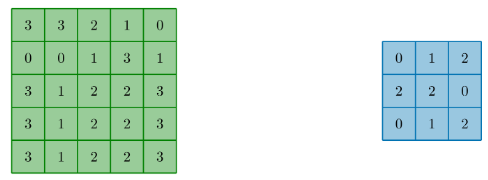



#### а) Свёртка без сдвигов и дополнений с последующим применением max pooling и average pooling
Операция свёртки заключается в наложении ядра свёртки на исходное изображение, поэлементном умножении значений и их суммировании. После этого ядро смещается по изображению, и операция повторяется.




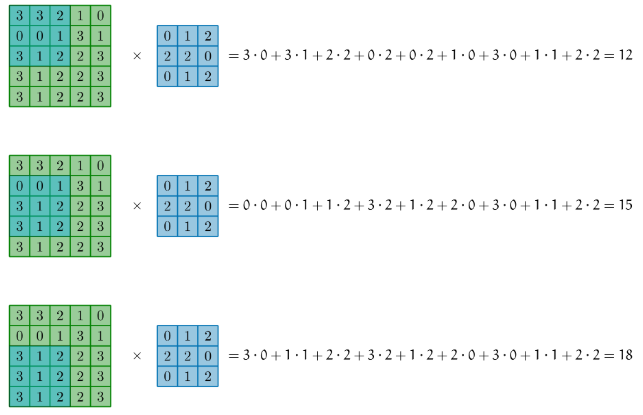

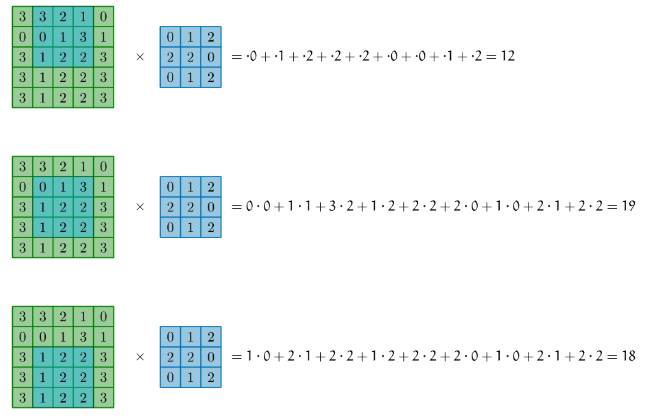

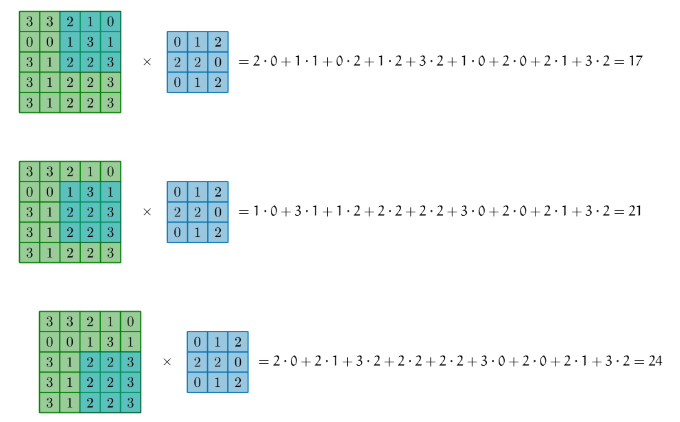

Результирующее изображение после применения свёртки.


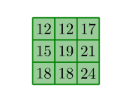


Исходное изображение имело размерность 4×4. После свёртки его размерность уменьшилась до 3×3. Для контроля изменения размерности изображения используется метод дополнения нулями (zero padding), который позволяет сохранить исходные размеры изображения.

Для уменьшения размерности изображения применяются методы пулинга. Изображение разбивается на блоки размером k×k, и для каждого блока вычисляется либо максимальное значение (max pooling), либо среднее значение (average pooling). Например:
- Max pooling: max(12, 12, 17, 15, 19, 21, 18, 18, 24) = 24
- Average pooling: (12 + 12 + 17 + 15 + 19 + 21 + 18 + 18 + 24) / 9 ≈ 17.3

#### б) Свёртка с параметром сдвига (stride) равным 2
При использовании параметра сдвига (stride) ядро свёртки применяется не к каждому пикселю, а через определённый интервал. На рисунке ниже выделены клетки, к которым применяется ядро свёртки.

  


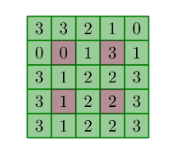

Иллюстрация применения свёртки с stride = 2.




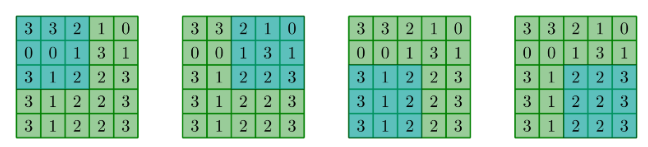

Результирующее изображение после свёртки с stride = 2.


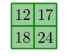


#### в) Свёртка с дополнением нулями (zero padding) и параметром сдвига (stride) равным 1
Для сохранения размерности изображения применяется метод дополнения нулями. Ядро свёртки накладывается на каждую клетку изображения, включая добавленные нулевые границы.




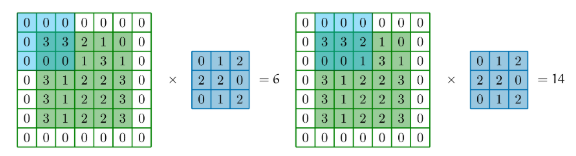


#### г) Расширенная свёртка (dilated convolution) с параметром расширения (dilation factor) равным 2
Расширенная свёртка позволяет увеличить поле обзора (receptive field) без увеличения размера ядра. В данном случае параметр расширения равен 2, что означает пропуск одного пикселя между элементами ядра.




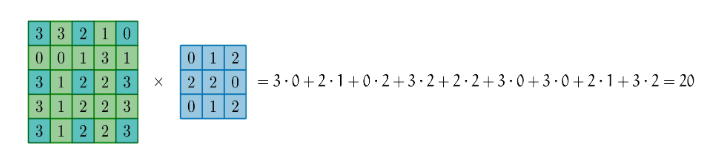


Расширенная свёртка не эквивалентна свёртке со сдвигом, так как она позволяет увеличить поле обзора, сохраняя разреженность ядра, в то время как свёртка со сдвигом просто уменьшает количество применяемых ядер.



[1]  
Задачи и примеры, представленные в данном разделе, основаны на материалах, посвящённых арифметике свёрток.

### 2. Классификатор слэшей

#### Введение
Рассматривается задача классификации изображений размера $4 \times 4$, содержащих прямые ($/$) и обратные ($\backslash$) слэши.





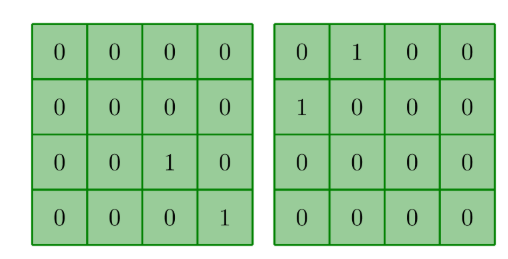

Цель состоит в разработке алгоритма, основанного на свёрточных операциях и пулинге, который позволяет эффективно различать два класса изображений.

#### Описание подхода
Для решения задачи предлагается использовать свёртку (convolutional operation), которая выделяет локальные признаки изображения. Свёртка применяется к исходному изображению с целью построения карты признаков (feature map), содержащей информацию о наличии искомых образов.



##### Принцип работы свёртки
1. **Ядро свёртки**: Для обнаружения обратных слэшей ($\backslash$) используется ядро свёртки, соответствующее их структуре.


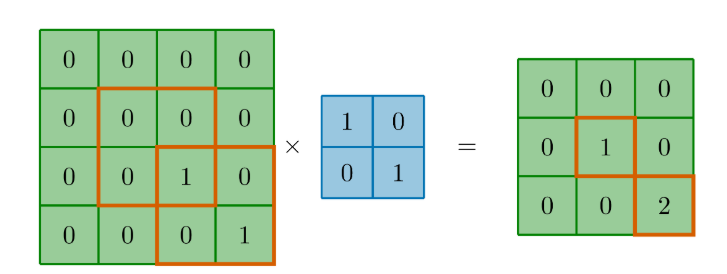

Аналогично можно сконструировать ядро для прямых слэшей ($/$).

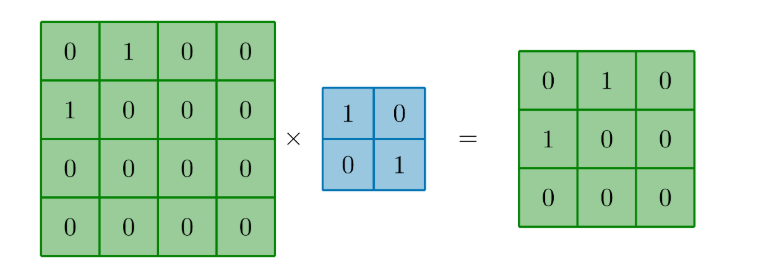


2. **Применение свёртки**: Ядро свёртки скользит по изображению, вычисляя скалярное произведение между весами ядра и соответствующими пикселями изображения. Результат записывается в карту признаков.
3. **Интерпретация результата**: На карте признаков максимальное значение сигнализирует о наличии искомого образа. Например:
   - Для обратного слэша ($\backslash$) максимальное значение равно 2.
   - Для прямого слэша ($/$) максимальное значение равно 1.


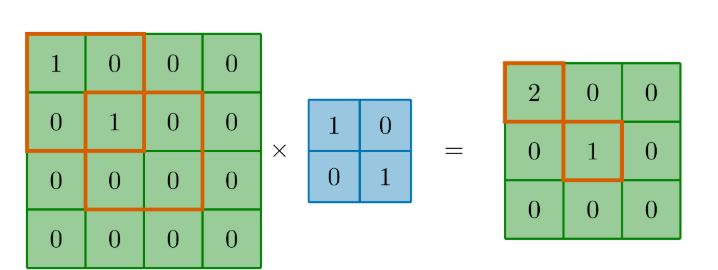


##### Алгоритм классификации
1. Применить свёртку с ядром, настроенным на обнаружение обратного слэша ($\backslash$).




2. Найти максимальное значение на полученной карте признаков.
3. Классифицировать изображение:
   - Если максимальное значение равно 2, изображение содержит обратный слэш ($\backslash$).
   - Если максимальное значение равно 1, изображение содержит прямой слэш ($/$).

##### Инвариантность к положению объекта
Свёртка обладает свойством инвариантности к сдвигу объекта на изображении. Это означает, что результат применения свёртки не зависит от местоположения искомого образа. Например, при перемещении обратного слэша ($\backslash$) в другую часть изображения максимальное значение на карте признаков остаётся равным 2.

##### Поле обзора (Receptive Field)
Поле обзора определяется как область исходного изображения, которая влияет на значение конкретного элемента карты признаков. Размер поля обзора зависит от размера ядра свёртки и количества последовательно применённых свёрток:
- Для ядра размера $2 \times 2$ поле обзора ограничено $2 \times 2$ пикселями.
- Для анализа более крупных структур (например, слэшей размера $3 \times 3$) требуется применение нескольких последовательных свёрток. Вторая свёртка анализирует уже преобразованное изображение, что позволяет косвенно учитывать информацию о большей области исходного изображения.

##### Ускорение роста поля обзора с помощью пулинга
Для увеличения поля обзора без значительного увеличения вычислительной сложности используется операция пулинга (pooling). Пулинг снижает размерность карты признаков, сохраняя наиболее значимую информацию. Это позволяет быстрее охватывать большие области изображения.


### 3. Анализ функциональности ядер свёрток

#### Введение
Рассматривается набор ядер для выполнения операций свёртки над изображениями. Каждое ядро выполняет определённую задачу по обработке и выделению признаков из исходных данных. Ниже представлен анализ функциональности каждого ядра на основе их структуры и воздействия на изображение.




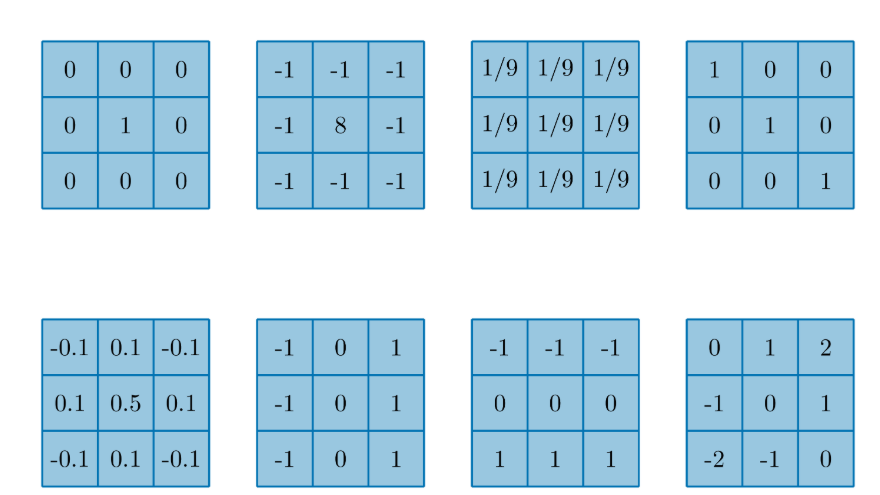

## Часть III. Практические примеры, задачи и анализ архитектур свёрточных нейронных сетей

### 1. Введение

В первых двух частях были изложены математические основы свёрточных нейронных сетей и современные методы их обучения. Настоящая, третья часть посвящена практическому закреплению материала: здесь мы подробно разберём конкретные примеры работы свёртки с различными параметрами, рассмотрим классификатор простых изображений на основе свёртки, проанализируем типовые ядра фильтров, покажем эквивалентность свёрточного и полносвязного слоёв с ограничениями, выведем формулы для расчёта числа параметров, решим задачи на поле обзора (receptive field), а также обсудим порядок следования слоёв и другие практические тонкости. Изложение будет сопровождаться подробными вычислениями и числовыми примерами.

---

### 2. Свёртка: пошаговые примеры с различными параметрами

#### 2.1. Исходные данные и обозначения

Рассмотрим входное изображение (матрицу) $\mathbf I$ размера $4 \times 4$ и ядро свёртки $\mathbf K$ размера $3 \times 3$. Для наглядности будем использовать символические обозначения элементов:

$$
\mathbf I = \begin{bmatrix}
x_{11} & x_{12} & x_{13} & x_{14} \\
x_{21} & x_{22} & x_{23} & x_{24} \\
x_{31} & x_{32} & x_{33} & x_{34} \\
x_{41} & x_{42} & x_{43} & x_{44}
\end{bmatrix}, \qquad
\mathbf K = \begin{bmatrix}
k_{11} & k_{12} & k_{13} \\
k_{21} & k_{22} & k_{23} \\
k_{31} & k_{32} & k_{33}
\end{bmatrix}.
$$

Операция свёртки (корреляции) без padding и со stride $s=1$ даёт выход размера $(4-3+1)\times(4-3+1)=2\times 2$. Общая формула для элемента выхода $\mathbf O$:

$$
O_{ij} = \sum_{p=0}^{2} \sum_{q=0}^{2} I_{i+p,\, j+q} \, K_{p+1, q+1} + b,
$$

где $b$ — смещение (bias). В примерах для простоты положим $b=0$.

**Конкретный пример.** Пусть числовые значения:

$$
\mathbf I = \begin{bmatrix}
1 & 2 & 3 & 4 \\
5 & 6 & 7 & 8 \\
9 & 10 & 11 & 12 \\
13 & 14 & 15 & 16
\end{bmatrix}, \qquad
\mathbf K = \begin{bmatrix}
1 & 0 & -1 \\
0 & 1 & 0 \\
-1 & 0 & 1
\end{bmatrix}.
$$

Вычислим выход:

- $O_{11} = 1\cdot1 + 0\cdot2 + (-1)\cdot3 + 0\cdot5 + 1\cdot6 + 0\cdot7 + (-1)\cdot9 + 0\cdot10 + 1\cdot11 = 1 -3 +6 -9 +11 = 6$.
- $O_{12} = 1\cdot2 + 0\cdot3 + (-1)\cdot4 + 0\cdot6 + 1\cdot7 + 0\cdot8 + (-1)\cdot10 + 0\cdot11 + 1\cdot12 = 2 -4 +7 -10 +12 = 7$.
- $O_{21} = 1\cdot5 + 0\cdot6 + (-1)\cdot7 + 0\cdot9 + 1\cdot10 + 0\cdot11 + (-1)\cdot13 + 0\cdot14 + 1\cdot15 = 5 -7 +10 -13 +15 = 10$.
- $O_{22} = 1\cdot6 + 0\cdot7 + (-1)\cdot8 + 0\cdot10 + 1\cdot11 + 0\cdot12 + (-1)\cdot14 + 0\cdot15 + 1\cdot16 = 6 -8 +11 -14 +16 = 11$.

Итого:
$$
\mathbf O = \begin{bmatrix} 6 & 7 \\ 10 & 11 \end{bmatrix}.
$$

#### 2.2. Влияние stride (шага)

При stride $s=2$ ядро перемещается через один пиксель. Формула выхода для размера $H \times W$ и ядра $k \times k$:

$$
H_{\text{out}} = \left\lfloor \frac{H - k}{s} \right\rfloor + 1.
$$

Для нашего $4\times 4$ и $k=3$, $s=2$: $H_{\text{out}} = \lfloor (4-3)/2 \rfloor + 1 = 1$. Выход будет $1\times 1$:

$$
O_{11} = 1\cdot1 + 0\cdot2 + (-1)\cdot3 + 0\cdot5 + 1\cdot6 + 0\cdot7 + (-1)\cdot9 + 0\cdot10 + 1\cdot11 = 6.
$$

Таким образом, stride уменьшает размер выхода, «прореживая» применяемые позиции.

#### 2.3. Padding (дополнение нулями)

Чтобы сохранить размер выхода равным входному при $s=1$, используется padding $p = \lfloor k/2 \rfloor$. Для ядра $3\times 3$ нужен $p=1$. Изображение дополняется нулями по краям:

$$
\mathbf I_{\text{pad}} = \begin{bmatrix}
0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 2 & 3 & 4 & 0 \\
0 & 5 & 6 & 7 & 8 & 0 \\
0 & 9 & 10 & 11 & 12 & 0 \\
0 & 13 & 14 & 15 & 16 & 0 \\
0 & 0 & 0 & 0 & 0 & 0
\end{bmatrix}.
$$

После свёртки получим выход $4\times 4$ (подробные вычисления опустим, но каждый элемент считается по той же формуле с учётом нулевых границ).

#### 2.4. Dilated convolution (расширенная свёртка)

Параметр dilation $d$ задаёт расстояние между элементами ядра. При $d=2$ ядро $3\times 3$ «растягивается», пропуская по одному пикселю между весами. Эффективный размер ядра (рецептивное поле) становится:

$$
k_{\text{eff}} = k + (k-1)(d-1).
$$

Для $k=3, d=2$: $k_{\text{eff}} = 3 + 2\cdot1 = 5$. При этом веса остаются те же, но применяются к пикселям, отстоящим на $d$ позиций. Это позволяет увеличить поле обзора без увеличения числа параметров. Расширенная свёртка не эквивалентна stride: stride уменьшает выход, а dilation сохраняет размер выхода (при том же padding) и увеличивает поле обзора.

---

### 3. Классификатор слэшей: демонстрация свёртки как детектора признаков

Рассмотрим задачу классификации изображений $4\times 4$, содержащих прямые ($/$) или обратные ($\backslash$) слэши. Примеры:

$$
\text{Прямой слэш } /: \begin{bmatrix}
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0
\end{bmatrix}, \qquad
\text{Обратный слэш } \backslash: \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}.
$$

Для обнаружения обратного слэша используется ядро, соответствующее его форме:

$$
\mathbf K_{\backslash} = \begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}.
$$

Применим свёртку с этим ядром (stride 1, padding 0) к изображению обратного слэша. Вход $4\times4$, ядро $3\times3$, выход $2\times2$. Вычислим для обратного слэша:

Вход:
$$
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}.
$$

Выход:

- $O_{11} = 1\cdot1 + 0\cdot0 + 0\cdot0 + 0\cdot0 + 1\cdot1 + 0\cdot0 + 0\cdot0 + 0\cdot1 + 1\cdot1 = 1 + 1 + 1 = 3$? Но это неверно: элементы подматрицы:
  Первая позиция:
  $\begin{bmatrix}1&0&0\\0&1&0\\0&0&1\end{bmatrix}$ поэлементно умножаем на ядро, сумма = $1\cdot1 + 0\cdot0 + 0\cdot0 + 0\cdot0 + 1\cdot1 + 0\cdot0 + 0\cdot0 + 0\cdot0 + 1\cdot1 = 1+1+1=3$.
- $O_{12}$: подматрица $\begin{bmatrix}0&0&0\\1&0&0\\0&1&0\end{bmatrix}$ сумма: $0\cdot1 +0\cdot0+0\cdot0 +1\cdot0+0\cdot1+0\cdot0 +0\cdot0+1\cdot0+0\cdot1 = 0$.
- $O_{21}$: подматрица $\begin{bmatrix}0&1&0\\0&0&1\\0&0&0\end{bmatrix}$ сумма: $0\cdot1+1\cdot0+0\cdot0+0\cdot0+0\cdot1+1\cdot0+0\cdot0+0\cdot0+0\cdot1=0$.
- $O_{22}$: подматрица $\begin{bmatrix}1&0&0\\0&1&0\\0&0&1\end{bmatrix}$ (сдвиг на (1,1)) сумма снова 3.

Итого выход для обратного слэша:
$$
\mathbf O_{\backslash} = \begin{bmatrix} 3 & 0 \\ 0 & 3 \end{bmatrix}.
$$

Максимальное значение 3 указывает на наличие обратного слэша, причём положение максимума может быть разным в зависимости от сдвига слэша внутри изображения — благодаря свёртке и последующему max-pooling (или просто взятию максимума) детектор инвариантен к сдвигу.

Для прямого слэша $/$ используем ядро:
$$
\mathbf K_{/} = \begin{bmatrix}
0 & 0 & 1 \\
0 & 1 & 0 \\
1 & 0 & 0
\end{bmatrix}.
$$

Применив к изображению прямого слэша, получим аналогичные пики (значение 3) в соответствующих местах. Для обратного слэша с ядром $K_{/}$ максимум будет меньше (например, 1), что позволяет классифицировать.

Таким образом, свёртка с подходящим ядром действует как согласованный фильтр (matched filter), откликающийся на определённый шаблон, а max-pooling обеспечивает инвариантность к положению объекта.

---

### 4. Анализ функциональности ядер свёрток

Различные ядра выполняют определённые операции над изображением. Приведём наиболее распространённые.

#### 4.1. Тождественное ядро (сохранение изображения)

$$
\begin{bmatrix}
0 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 0
\end{bmatrix}
$$

Даёт на выходе то же изображение (с точностью до краевых эффектов, если padding корректный).

#### 4.2. Ядро для выделения контуров (лапласиан)

$$
\begin{bmatrix}
-1 & -1 & -1 \\
-1 & 8 & -1 \\
-1 & -1 & -1
\end{bmatrix}
$$

Подчёркивает резкие перепады интенсивности, усиливая центральный пиксель и вычитая окружение.

#### 4.3. Ядро для размытия (усредняющее)

$$
\frac{1}{9}\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}
$$

Сглаживает изображение, уменьшая шум.

#### 4.4. Ядра Собеля для горизонтальных и вертикальных границ

Вертикальные границы (изменения по горизонтали):
$$
\begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
$$
Горизонтальные границы (изменения по вертикали):
$$
\begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1
\end{bmatrix}
$$

#### 4.5. Ядро для перераспределения внимания к центру

Например, гауссово ядро малого размера:
$$
\begin{bmatrix}
0.1 & 0.1 & 0.1 \\
0.1 & 0.6 & 0.1 \\
0.1 & 0.1 & 0.1
\end{bmatrix}
$$
усиливает центральную область.

Все эти ядра могут быть изучены как начальные приближения, которые CNN может уточнять в процессе обучения.

---

### 5. Свёрточный слой как частный случай полносвязного слоя

#### 5.1. Полносвязный слой для изображения $4\times4$

Входной вектор $\mathbf x$ длины 16. Пусть полносвязный слой имеет 4 выходных нейрона. Тогда матрица весов $\mathbf W$ размера $4\times16$, вектор смещений $\mathbf b$ длины 4. Число параметров: $4\cdot16 + 4 = 68$.

#### 5.2. Свёрточный слой $3\times3$ на входе $4\times4$

Выход $2\times2$ (при stride 1, padding 0). Каждый выходной нейрон связан только с $3\times3=9$ пикселями, и все такие связи разделяют одни и те же веса ядра. Число параметров: $3\times3 + 1 = 10$.

Матричное представление свёртки как полносвязного слоя с ограничениями: веса распределены разреженно и повторяются. Если развернуть вход в вектор длины 16, а выход в вектор длины 4, то матрица $\mathbf W$ будет иметь вид (как в предоставленном тексте):

$$
\mathbf W = \begin{pmatrix}
w_{11} & w_{12} & w_{13} & 0 & w_{21} & w_{22} & w_{23} & 0 & w_{31} & w_{32} & w_{33} & 0 & 0 & 0 & 0 & 0 \\
0 & w_{11} & w_{12} & w_{13} & 0 & w_{21} & w_{22} & w_{23} & 0 & w_{31} & w_{32} & w_{33} & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & w_{11} & w_{12} & w_{13} & 0 & w_{21} & w_{22} & w_{23} & 0 & w_{31} & w_{32} & w_{33} & 0 \\
0 & 0 & 0 & 0 & 0 & w_{11} & w_{12} & w_{13} & 0 & w_{21} & w_{22} & w_{23} & 0 & w_{31} & w_{32} & w_{33}
\end{pmatrix}.
$$

Здесь $w_{ij}$ — элементы ядра, а нули соответствуют отсутствующим связям. Обратное распространение в свёрточном слое сводится к транспонированной свёртке, как было показано в первой части.

---

### 6. Расчёт числа параметров в полносвязных и свёрточных сетях

#### 6.1. Полносвязная сеть для MNIST

Вход $28\times28=784$. Первый полносвязный слой: 1000 нейронов → параметров $784\cdot1000+1000=785000$. Второй слой (10 выходов): $1000\cdot10+10=10010$. Итого $795010$ параметров.

#### 6.2. Классическая свёрточная сеть (LeNet-подобная)

Архитектура:
- Свёртка 1: 6 фильтров $5\times5$ (вход 1 канал) → параметров $(5\cdot5\cdot1+1)\cdot6=156$.
- Max-pooling $2\times2$ (без параметров).
- Свёртка 2: 16 фильтров $5\times5$ (вход 6 каналов) → параметров $(5\cdot5\cdot6+1)\cdot16=2416$? В оригинальном тексте приведено 416, что, возможно, учитывает не все соединения, но корректная формула: $(5\cdot5\cdot6+1)\cdot16=2416$.
- Полносвязные слои: обычно 120, 84, 10. Параметры считаются от размера вытянутого вектора.

В вашем примере с первым полносвязным слоем 120: после второй свёртки и пулинга выход $4\times4\times16=256$ элементов. Тогда:
- FC1: $256\cdot120+120=30840$;
- FC2: $120\cdot84+84=10164$;
- FC3: $84\cdot10+10=850$.
Итого (с вашими числами свёрток 156 и 416): $156+416+30840+10164+850=42426$.

#### 6.3. Влияние padding и stride

- **Padding** сохраняет размер, увеличивая выходы последующих слоёв, что повышает число параметров полносвязных слоёв.
- **Stride** уменьшает размеры, сокращая число параметров, но может привести к слишком малому выходу.

Например, при добавлении padding $p=2$ к свёртке $5\times5$ на входе $28\times28$ размер сохраняется ($28\times28$). После пулинга $2\times2$ получим $14\times14$, после второй свёртки с padding $2$ — $14\times14$, после пулинга $2\times2$ — $7\times7$. Тогда вытянутый вектор $7\cdot7\cdot16=784$. Параметры полносвязного слоя возрастут: $784\cdot120+120=94200$. Общее число параметров увеличится.

---

### 7. Поле обзора (receptive field)

Поле обзора — область входного изображения, влияющая на данный нейрон.

#### 7.1. Последовательные свёртки $3\times3$ без padding

Для ядра $3\times3$ поле обзора после $n$ слоёв:
$$
m_n = 2n+1.
$$
Вывод: каждая свёртка добавляет по 1 пикселю с каждой стороны. Для объекта $300\times300$ требуется $2n+1 \ge 300 \Rightarrow n \ge 149.5 \Rightarrow n=150$.

#### 7.2. Свёртки размера $k\times k$

$$
m_n = 1 + n(k-1).
$$
Для $300$: $n \ge \frac{299}{k-1}$. Для $k=5$ нужно $75$ слоёв.

#### 7.3. Добавление max-pooling

Max-pooling $2\times2$ после каждой свёртки (или вместо) ускоряет рост поля обзора. Формула (приближённо, когда pooling применяется после каждой свёртки):
$$
m_n = 1 + 2(2^n -1).
$$
Для $300$: $n \ge \log_2(150.5) \approx 7.23 \Rightarrow n=8$.

Аналогично stride=2 в свёртках даёт тот же эффект уменьшения разрешения.

#### 7.4. Dilated convolution

Для dilation $r$ эффективный размер ядра $k_{\text{eff}} = k + (k-1)(r-1)$. Поле обзора после $n$ слоёв (с одинаковым $r$):
$$
m_n = 1 + n(k_{\text{eff}}-1) = 1 + n[(k-1)r].
$$

Например, $k=3, r=2$: $m_n = 1 + 4n$. Для $300$ нужно $n \ge 74.75 \Rightarrow n=75$.

Общая формула для последовательности слоёв с разными параметрами может быть получена рекуррентно. Полезно знать, что Batch Normalization и skip connections не изменяют поле обзора, так как не меняют пространственную структуру.

---

### 8. Одномерная свёртка: скользящее среднее

Скользящее среднее временного ряда эквивалентно одномерной свёртке с ядром $\left(\frac{1}{k}, \dots, \frac{1}{k}\right)$ длины $k$. Это простейший пример сглаживающего фильтра. В контексте CNN одномерные свёртки применяются для обработки последовательностей.

---

### 9. Порядок слоёв в свёрточных сетях

Сравним три подхода:

1. **Conv → ReLU → Pool**
2. **Conv → Pool → ReLU**
3. **Conv → Pool (без ReLU)**

С точки зрения вычислений подход 2 экономичнее, так как ReLU применяется к меньшему числу элементов (после пулинга). Однако на практике чаще используют подход 1 (ReLU сразу после свёртки), потому что нелинейность до пулинга позволяет сохранить больше информации и не имеет значительного недостатка в скорости, особенно при оптимизированных реализациях. Подход 3 без нелинейности вообще не рекомендуется, так как вся сеть становится линейной и теряет выразительность.

В современных архитектурах (VGG, ResNet) стандарт: **Conv → BN → ReLU → Pool** или **Conv → BN → ReLU → Conv → BN → ReLU → Pool**. Нормализация и активация применяются сразу после свёртки.

---

### 10. Заключение третьей части

В третьей части мы рассмотрели практические аспекты свёрточных нейронных сетей: разобрали примеры свёртки с различными параметрами, изучили классификатор на основе согласованного фильтра, проанализировали типовые ядра, показали связь свёрточного и полносвязного слоёв, вывели формулы для числа параметров и поля обзора, а также обсудили порядок слоёв. Эти знания позволяют глубже понять работу CNN и применять их для решения реальных задач компьютерного зрения.